In [ ]:
import fidle
print(fidle.__file__)


c:\fidle-tp\fidle-env\lib\site-packages\fidle\__init__.py


#### Prediction of a 2D trajectory via RNN

1. Artificial dataset generation and prediction attempt via a recurrent network, using Keras 3 and PyTorch

**Objectives :**
    - Understanding the use of a recurrent neural network
2. What we're going to do :
- Generate an artificial dataset
- dataset preparation
- Doing our testing
- Making predictions

In [4]:
datasets_dir = r"C:\Users\Kered\ML_DVRC_2025\Lecture9\data"

In [5]:
import os
from datetime import datetime

# --- Dataset directory (local, sans FIDLE)
datasets_dir = r"C:\Users\Kered\ML_DVRC_2025\Lecture9\data"

# --- Run info (équivalent minimal FIDLE)
run_id = "K3LADYB1_" + datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = os.path.join(os.getcwd(), "runs", run_id)

# --- Create run folders
os.makedirs(run_dir, exist_ok=True)
os.makedirs(os.path.join(run_dir, "figures"), exist_ok=True)
os.makedirs(os.path.join(run_dir, "models"), exist_ok=True)

print("run_id      :", run_id)
print("run_dir     :", run_dir)
print("datasets_dir:", datasets_dir)


run_id      : K3LADYB1_20260126_170001
run_dir     : c:\Users\Kered\ML_DVRC_2025\Lecture9\Lab\runs\K3LADYB1_20260126_170001
datasets_dir: C:\Users\Kered\ML_DVRC_2025\Lecture9\data


In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

#import keras
import numpy as np
from math import cos, sin
import random

import fidle



#### Step 1 - Import and init

In [4]:
#About dataset

max_t        = 1000
delta_t      = 0.01
features_len = 2


sequence_len = 20
predict_len  = 5

# ---- About training
#
scale         = .2       # Percentage of dataset to be used (1=all)
train_prop    = .8       # Percentage for train (the rest being for the test)
batch_size    = 32
epochs        = 5
fit_verbosity = 1        # 0 = silent, 1 = progress bar, 2 = one line per epoch

In [5]:
fidle.override('scale', 'train_prop', 'sequence_len', 'predict_len', 'batch_size', 'epochs', 'fit_verbosity')

#### Step 2 - Generation of the dataset

In [6]:
def ladybug_init(s=122):
    
    if s>0 : random.seed(s)
    ladybug_init.params_x = [ random.gauss(0.,1.) for u in range(8)]
    ladybug_init.params_y = [ random.gauss(0.,1.) for u in range(8)]
    
def ladybug_move(t):

    [ax1, ax2, ax3, ax4, kx1, kx2, kx3, kx4] = ladybug_init.params_x
    [ay1, ay2, ay3, ay4, ky1, ky2, ky3, ky4] = ladybug_init.params_y
    
    x = ax1*sin(t*(kx1+20)) + ax2*cos(t*(kx2+10)) + ax3*sin(t*(kx3+5)) + ax4*cos(t*(kx4+5))
    y = ay1*cos(t*(ky1+20)) + ay2*sin(t*(ky2+10)) + ay3*cos(t*(ky3+5)) + ay4*sin(t*(ky4+5)) 

    return x,y

#### 2.2 - Get some positions, and build a rescaled and normalized dataset

In [7]:
# ---- Get positions
#
ladybug_init(s=16)
x,y = 0,0
positions=[]
for t in np.arange(0., max_t, delta_t):
    x,y = ladybug_move(t)
    positions.append([x,y])

# ---- Build rescaled dataset
#
n = int( len(positions)*scale )
dataset = np.array(positions[:n])

k = int(len(dataset)*train_prop)
x_train = dataset[:k]
x_test  = dataset[k:]

# ---- Normalize
#
mean = x_train.mean()
std  = x_train.std()
x_train = (x_train - mean) / std
x_test  = (x_test  - mean) / std

print("Dataset generated.")
print("Train shape is : ", x_train.shape)
print("Test  shape is : ", x_test.shape)

Dataset generated.
Train shape is :  (16000, 2)
Test  shape is :  (4000, 2)


#### 2.3 - Have a look

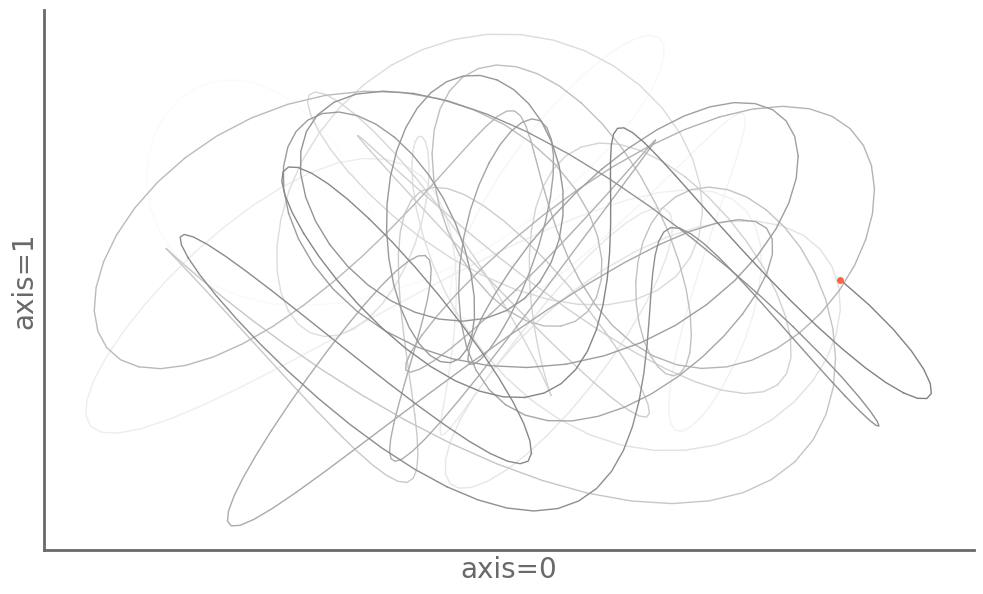

In [8]:
fidle.scrawler.serie_2d(x_train[:1000], figsize=(12,12), lw=1,ms=4,save_as='01-dataset')

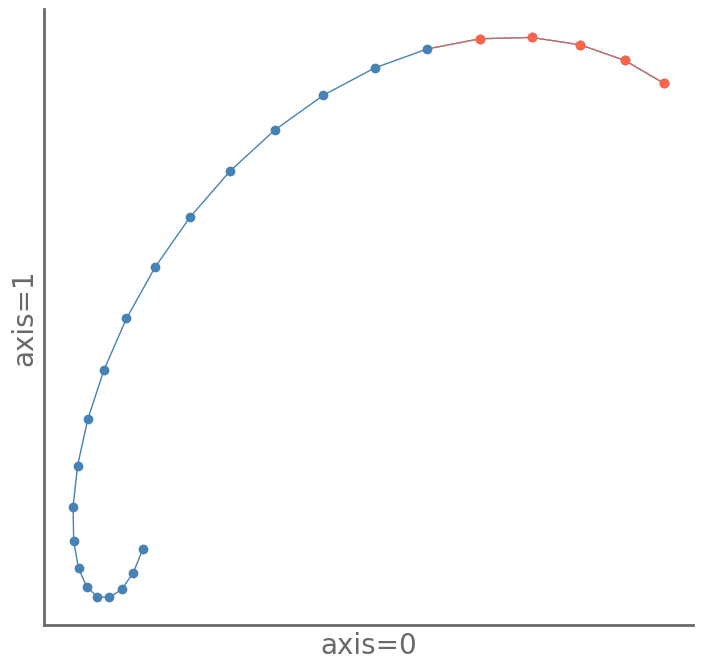

In [9]:
k1,k2 = sequence_len, predict_len
i = random.randint(0,len(x_test)-k1-k2)
j = i+k1

fidle.scrawler.segment_2d( x_test[i:j+k2], x_test[j:j+k2],ms=6, save_as='02-objectives')

#### 2.4 - Prepare sequences from datasets

In [10]:
# ---- Create sequences and labels for train and test
#
xs_train, ys_train=[],[]
all_i = np.random.permutation( len(x_train) - sequence_len - 1 )

for i in all_i:
    xs_train.append( x_train[ i : i+sequence_len ] )
    ys_train.append( x_train[ i+sequence_len+1 ]   )
    
xs_test, ys_test=[],[]
for i in range( len(x_test) - sequence_len - 1):
    xs_test.append( x_test[ i : i+sequence_len ] )
    ys_test.append( x_test[ i+sequence_len+1 ]   )

# ---- Convert to numpy / float16
    
xs_train = np.array(xs_train, dtype='float16')
ys_train = np.array(ys_train, dtype='float16')
xs_test  = np.array(xs_test,  dtype='float16')
ys_test  = np.array(ys_test,  dtype='float16')

In [11]:
fidle.utils.subtitle('About the splitting of our dataset :')

print('Number of sequences : ', len(xs_train))
print('xs_train shape      : ',xs_train.shape)
print('ys_train shape      : ',ys_train.shape)

fidle.utils.subtitle('What an xs look like :')
fidle.utils.np_print(xs_train[10] )
fidle.utils.subtitle('What an ys look like :')
fidle.utils.np_print(ys_train[10])

<br>**About the splitting of our dataset :**

Number of sequences :  15979
xs_train shape      :  (15979, 20, 2)
ys_train shape      :  (15979, 2)


<br>**What an xs look like :**

[[ 0.703  0.173]
 [ 0.915 -0.008]
 [ 1.106 -0.193]
 [ 1.273 -0.375]
 [ 1.41  -0.547]
 [ 1.515 -0.703]
 [ 1.585 -0.835]
 [ 1.619 -0.94 ]
 [ 1.617 -1.014]
 [ 1.58  -1.052]
 [ 1.51  -1.054]
 [ 1.41  -1.02 ]
 [ 1.283 -0.951]
 [ 1.136 -0.85 ]
 [ 0.971 -0.721]
 [ 0.797 -0.569]
 [ 0.617 -0.4  ]
 [ 0.44  -0.22 ]
 [ 0.27  -0.037]
 [ 0.113  0.142]]


<br>**What an ys look like :**

[-0.14   0.461]


#### Step 3 - Create a model

In [12]:
model = keras.models.Sequential()
model.add( keras.layers.InputLayer(shape=(sequence_len, features_len)) )
model.add( keras.layers.GRU(200, return_sequences=False, activation='relu') )
model.add( keras.layers.Dense(features_len) )

model.summary()

model.compile(optimizer='rmsprop', 
              loss='mse', 
              metrics   = ['mae'] )

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 200)            │       122,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           402 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,802 (479.70 KB)

 Trainable params: 122,802 (479.70 KB)

 Non-trainable params: 0 (0.00 B)

#### Step 4 - Train the model

4.1 Add Callbacks

In [18]:
os.makedirs(f'{run_dir}/models',   mode=0o750, exist_ok=True)
save_dir = f'{run_dir}/models/best_model.keras'

savemodel_callback = keras.callbacks.ModelCheckpoint( filepath=save_dir, monitor='val_mae', mode='max', save_best_only=True)

4.2 - Train the Model

In [19]:
chrono=fidle.Chrono()
chrono.start()

history=model.fit(xs_train,ys_train,
                  epochs  = epochs, 
                  verbose = fit_verbosity,
                  validation_data = (xs_test, ys_test),
                  callbacks = [savemodel_callback])


Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step - loss: 0.1285 - mae: 0.2399 - val_loss: 0.0139 - val_mae: 0.0937
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - loss: 0.0067 - mae: 0.0649 - val_loss: 0.0057 - val_mae: 0.0542
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - loss: 0.0032 - mae: 0.0440 - val_loss: 0.0027 - val_mae: 0.0414
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - loss: 0.0024 - mae: 0.0378 - val_loss: 0.0022 - val_mae: 0.0389
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - loss: 0.0019 - mae: 0.0340 - val_loss: 0.0024 - val_mae: 0.0349


#### Step 5 - Predict

##### 5.1 - Load model

In [20]:
loaded_model = keras.models.load_model(f'{run_dir}/models/best_model.keras')
print('Loaded.')

Loaded.


##### 5.2 - Make a 1-step prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
sequence shape      : (20, 2)
sequence true shape : (21, 2)
sequence pred shape : (1, 2)


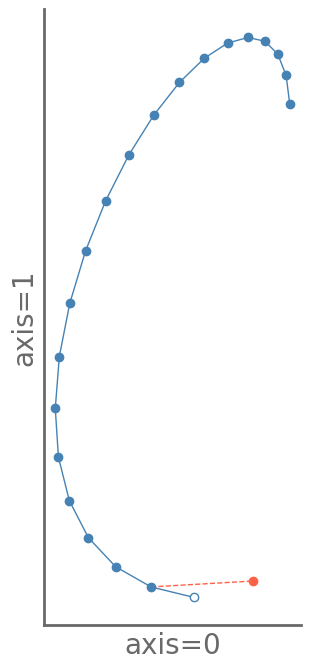

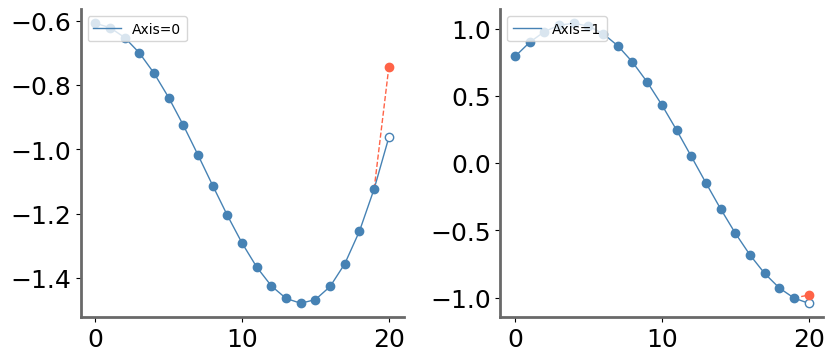

In [21]:
s=random.randint(0,len(x_test)-sequence_len)

sequence      = x_test[s:s+sequence_len]
sequence_true = x_test[s:s+sequence_len+1]

sequence_pred = loaded_model.predict( np.array([sequence]), verbose=fit_verbosity )

print('sequence shape      :',sequence.shape)
print('sequence true shape :',sequence_true.shape)
print('sequence pred shape :',sequence_pred.shape)

fidle.scrawler.segment_2d(sequence_true, sequence_pred, save_as='04-one-step-prediction')
fidle.scrawler.multivariate_serie(sequence_true, predictions=sequence_pred, labels=['Axis=0', 'Axis=1'],save_as='05-one-step-prediction-2axis')

##### 5.3 - Make n-steps prediction

- A longer term prediction, via a nice iteration function
- We will perform predictions to iteratively build our prediction.

In [22]:
def get_prediction(dataset, model, iterations=4):

    # ---- Initial sequence
    #
    s=random.randint(0,len(dataset)-sequence_len-iterations)

    sequence_pred = dataset[s:s+sequence_len].copy()
    sequence_true = dataset[s:s+sequence_len+iterations].copy()

    # ---- Iterate 
    #
    sequence_pred = list(sequence_pred)

    for i in range(iterations):
        sequence   = sequence_pred[-sequence_len:]
        prediction = model.predict( np.array([sequence]), verbose=fit_verbosity )
        sequence_pred.append(prediction[0])

    # ---- Extract the predictions    
    #
    prediction = np.array(sequence_pred[-iterations:])

    return sequence_true,prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


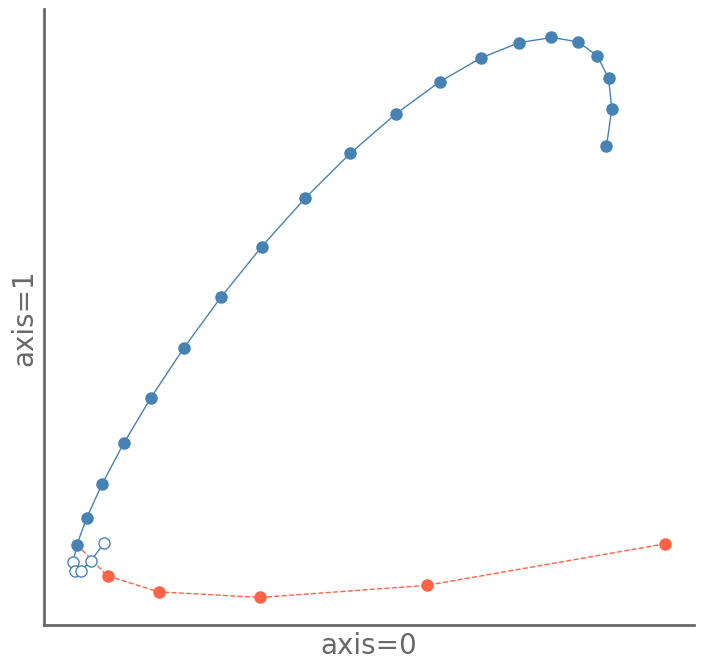

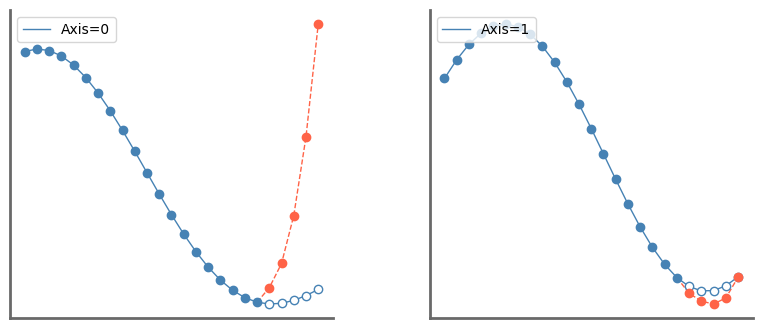

In [23]:
sequence_true, sequence_pred = get_prediction(x_test, loaded_model, iterations=5)

fidle.scrawler.segment_2d(sequence_true, sequence_pred, ms=8, save_as='06-n-steps-prediction-norm')
fidle.scrawler.multivariate_serie(sequence_true, predictions=sequence_pred, hide_ticks=True, labels=['Axis=0', 'Axis=1'],save_as='07-n-steps-prediction-norm')